# AIML CA2-PartA: Clustering

## 1. Loading Resources

### 1.1 Importing necessary packages

In [1]:
import pandas as pd
import numpy as np

# installing graphing libraries
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# normalization 
from sklearn.preprocessing import StandardScaler
#PCA
from sklearn.decomposition import PCA

# models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster

# matrices
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


### 1.2 Importing datasets

In [2]:
df= pd.read_csv(r"C:\Users\yanmy\AIML_Lab\AIML-CA2-Dataset\CA2-Customer-Data.csv")
df.head()

,CustomerID,Gender,Age,Income (k$),How Much They Spend
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. EDA 

### 2.1 General info

In [3]:
print(df.info(),'\n')
print(df.isnull().sum(),'\n')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           200 non-null    int64 
 1   Gender               200 non-null    object
 2   Age                  200 non-null    int64 
 3   Income (k$)          200 non-null    int64 
 4   How Much They Spend  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None 

CustomerID             0
Gender                 0
Age                    0
Income (k$)            0
How Much They Spend    0
dtype: int64 



,CustomerID,Age,Income (k$),How Much They Spend
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Age
- Range: 18–70
- Diverse age groups present
- **Decision:** Segment into age brackets for targeted marketing

#### Income
- Range: 15k–137k
- Wide variation with high earners
- **Decision:** Cluster into low/medium/high income groups for tiered product offerings

#### Spending
- Range: 1–99
- Spending not directly tied to income
- **Decision:** Identify high-value customers (high spending regardless of income) vs budget-conscious customers

#### Gender
- Balanced dataset (approx. equal male/female)
- **Decision:** Compare spending habits by gender to refine campaigns and need to encode in processing

#### Outliers
- Very high income (137k) and spending (99) values
- **Decision:** Treat separately or analyze as luxury customer segment


### 2.2 Distribution

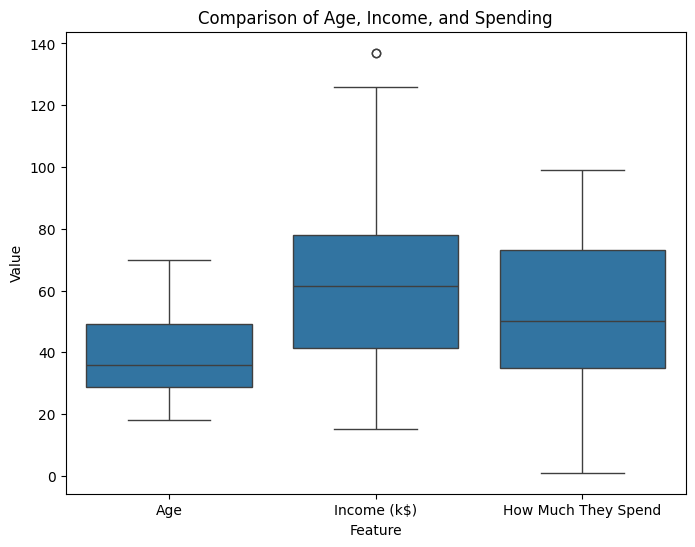

In [4]:
cols = ['Age', 'Income (k$)', 'How Much They Spend']

# Melt the dataframe into long format
df_melt = df[cols].melt(var_name='Feature', value_name='Value')

# Single boxplot comparing all features
plt.figure(figsize=(8,6))
sns.boxplot(x='Feature', y='Value', data=df_melt)
plt.title("Comparison of Age, Income, and Spending")
plt.show()

#### Age
- Slightly positive skewed
- **Decision:** Age can be used directly; apply StandardScaler for clustering

#### Income
- Shape: positive-skewed (more mid-income, fewer very high-income)
- **Decision:** StandardScaler before clustering.

#### Spending
- Shape: Slightly negative skewed.
- Not strongly skewed
- **Decision:** StandardScaler is fine.

#### Outliers

Age is fairly balanced, no extreme outliers.
Income is slightly right-skewed with an outlier near 137k and StandardScaler is to be used and need handling/removing outlier.  
Spending is spread across 1–99, no extreme outliers.

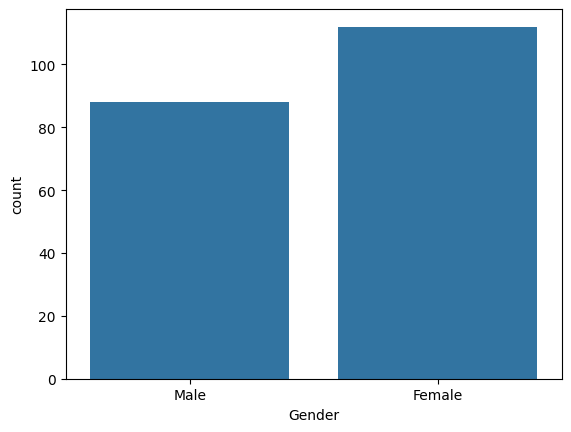

In [17]:
sns.countplot(x='Gender', data=df)
plt.show()

Data is balanced, and need encoding.

### 2.3 Coorlation

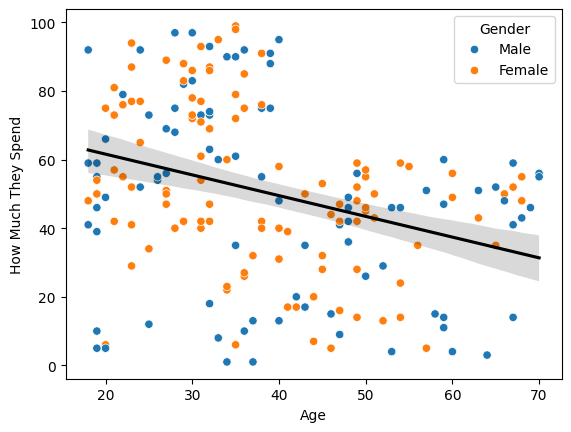

In [40]:
sns.scatterplot(x='Age', y='How Much They Spend', hue='Gender', data=df)

sns.regplot(x='Age', y='How Much They Spend', data=df,
            scatter=False, color='black')

plt.show()

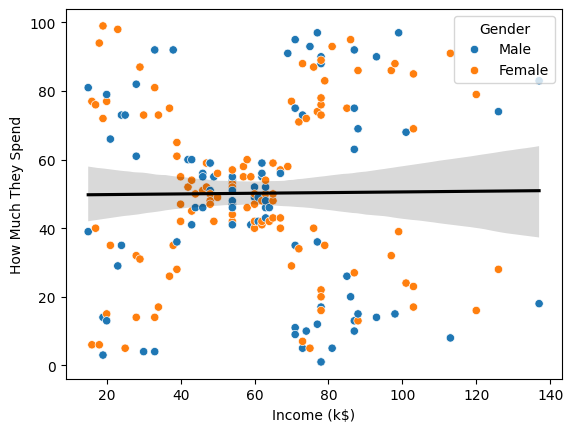

In [41]:
sns.scatterplot(x='Income (k$)', y='How Much They Spend', hue='Gender', data=df)

sns.regplot(x='Income (k$)', y='How Much They Spend', data=df,
            scatter=False, color='black')
plt.show()

#### Key Observations
- Moderate negative coorlation between Age and Spending: the older they are, the lesser they spend.
- No strong linear relationship between income and spending
- High-income group includes both very low and moderate spenders
- Gender distribution: both male and female spread similarly, no clear separation

#### Decisions
- **Marketing:** 
  - Focus on high-spending or younger clusters regardless of income
  - Target high-income but low-spending customers with promotions
- **Gender:** Not a major factor; campaigns should prioritize spending behavior over gender

## 3. Preprocessing

#### 3.1 Drop unnecessary columns

In [4]:
# 1. Drop CustomerID (identifier, not useful)
df = df.drop(columns=['CustomerID'])

#### 3.2 Fix names

Rename some features so that it is readable and easier to use.

In [5]:
df = df.rename(columns={
    "Income (k$)": "Income_k",
    "How Much They Spend": "Spending"
})

df.head()

,Gender,Age,Income_k,Spending
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### 3.3 Remove outliers

In [6]:
max_income = df['Income_k'].max()
print(max_income)
df = df[df['Income_k'] != max_income]

137


#### 3.4 Encoding

In [7]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

#### 3.5 Scale numerical features

In [8]:
scaler = StandardScaler()
df[['Age','Income_k','Spending']] = scaler.fit_transform(
    df[['Age','Income_k','Spending']]
)
df

,Gender,Age,Income_k,Spending
0,0,-1.425414,-1.779171,-0.435989
1,0,-1.282367,-1.779171,1.199413
2,1,-1.353890,-1.739447,-1.720949
3,1,-1.139319,-1.739447,1.043661
4,1,-0.567131,-1.699723,-0.397051
...,...,...,...,...
193,1,-0.066466,2.113819,1.588795
194,1,0.577246,2.391890,-1.331567
195,1,-0.281037,2.391890,1.121537
196,1,0.434198,2.630236,-0.864309


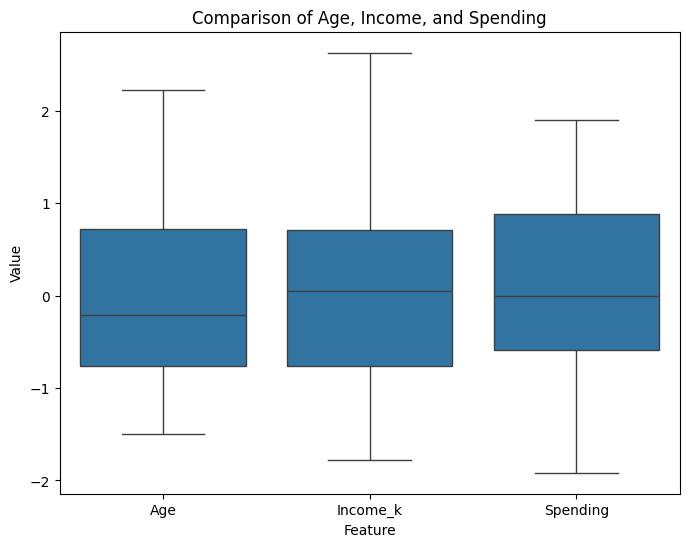

In [9]:
cols = ['Age', 'Income_k', 'Spending']

# Melt the dataframe into long format
df_melt = df[cols].melt(var_name='Feature', value_name='Value')

# Single boxplot comparing all features
plt.figure(figsize=(8,6))
sns.boxplot(x='Feature', y='Value', data=df_melt)
plt.title("Comparison of Age, Income, and Spending")
plt.show()

#### 3.6 Preprocessing Justification

- **Gender Encoding:**  
  - Gender is binary (Male/Female).  
  - Direct mapping (Male=0, Female=1) is sufficient and avoids unnecessary extra columns.  
  
- **Age:**  
  - StandardScaler (mean=0, std=1) ensures age contributes equally in clustering without bias from its raw scale.

- **Income (k$):**    
  - StandardScaler reduces the influence of large variance while preserving relative differences.  
  - MinMaxScaler would compress values too tightly due to the outlier, so StandardScaler is preferred.

- **Spending:**  
  - Spread across 1–99, relatively uniform.  
  - StandardScaler keeps spending comparable to Age/Income in clustering.  

- **CustomerID:**  
  - Pure identifier, no analytical meaning.  
  - Dropped to avoid noise in clustering.

- **Outliers**
  - **Distortion in scaling:** The extreme income value (~137k) would stretch the scale, making most other incomes appear compressed after standardization.  
  - **Clustering bias:** KMeans and PCA are sensitive to scale; one extreme point can pull centroids or principal components away from the majority.  
  - **Rare case:** Only 2 customers fall into this extreme range, so they don’t represent the typical population.  

## 4. Model Training

### 4.1 Applying PCA

#### 4.1.1 PCA Justification (Pre-training, based on EDA)
- Age and Spending show an inverse relationship, while Income remains positively skewed even after removing outliers.  
- PCA can handle the Age–Spending coorlation. 
- PCA highlights the strongest variance directions, improving separation of customer segments.  
- Decision: Apply PCA before clustering to simplify feature space and obtain clearer, more robust clusters and more precise visuals.

In [11]:
X = df[['Age','Income_k','Spending','Gender']]

sample_pca = PCA(n_components=4)
sample_pca.fit(X)
print(sample_pca.explained_variance_ratio_)
print(sample_pca.explained_variance_ratio_.cumsum())

[0.41016894 0.30824944 0.20651332 0.0750683 ]
[0.41016894 0.71841838 0.9249317  1.        ]


#### Why PCA with 2 Components (not 3)
- First 2 PCs explain about 72% of variance, capturing Age–Spending and Income patterns.  
- PC3 adds residual variance (20%) with limited interpretive value.  
- 2D PCA enables clear visualization and stronger clustering results.  
- Decision: Use 2 PCs for simplicity, variance coverage, and interpretability.

In [12]:
# Reduce to 2D 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) 

#### 4.1.2 The importance of each features in PCA

In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1','PCA2'],
    index=['Age','Income_k','Spending','Gender']
)
print(loadings)

              PCA1      PCA2
Age       0.706495  0.029070
Income_k -0.010610  0.999325
Spending -0.706460  0.015029
Gender   -0.040825 -0.016714


#### PCA Interpretation

**PCA1 (First Component)**  
- Age: +0.706 : strong positive contribution  
- Spending: −0.706 :strong negative contribution  
- Income: −0.011 : negligible  
- Gender: −0.041 : negligible  

Meaning: PCA1 represents an Age vs Spending trade‑off.  
- High PCA1 score : older individuals who spend less.  
- Low PCA1 score : younger individuals who spend more.  


**PCA2 (Second Component)**  
- Income: +0.999 : dominant positive contribution  
- Age, Spending, Gender: near zero : minimal contribution  

Meaning: PCA2 is essentially an Income axis.  
- High PCA2 score : high‑income individuals.  
- Low PCA2 score : low‑income individuals.  


**Overall Insight**  
- **PCA1** separates groups by **Age vs Spending behavior**.  
- **PCA2** separates groups by **Income level**.  
- **Gender** contributes very little to either component, so it does not explain much variance in this dataset.

When visualizing clusters in PCA space:  
- Movement along x‑axis (PCA1) = differences in Age vs Spending.  
- Movement along y‑axis (PCA2) = differences in Income.

### 4.2 Training Models

#### 4.2.1 Building Function for Visualization

In [16]:
# Helper function to plot clusters
def plot_clusters(X_pca, labels, title, centers=None):
    plt.figure(figsize=(6,4))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='rainbow', s=40)
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], c='green', s=200, alpha=0.8, marker='o')
    plt.title(title)
    explained = pca.explained_variance_ratio_
    plt.xlabel("Age (+) vs Spending (-)")
    plt.ylabel("Income")
    plt.show()


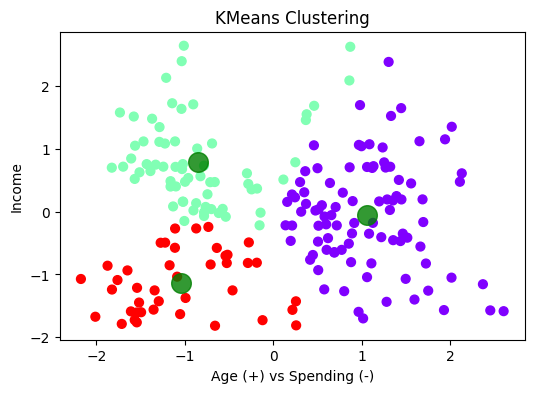

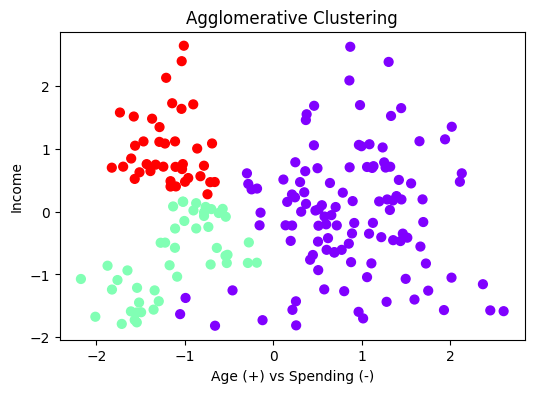

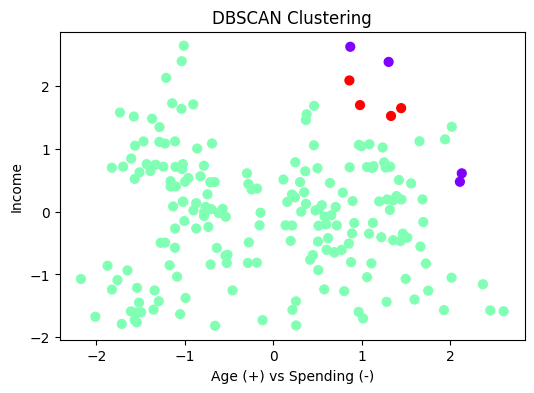

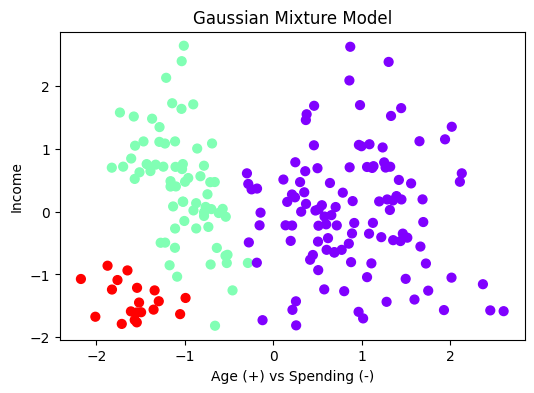

In [17]:
# 1. KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)
plot_clusters(X_pca, labels_kmeans, "KMeans Clustering", centers=kmeans.cluster_centers_)

# 2. Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_pca)
plot_clusters(X_pca, labels_agg, "Agglomerative Clustering")

# 3. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
labels_dbscan = dbscan.fit_predict(X_pca)
plot_clusters(X_pca, labels_dbscan, "DBSCAN Clustering")

# 4. Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)
plot_clusters(X_pca, labels_gmm, "Gaussian Mixture Model")

In [18]:
print("KMeans Silhouette:", silhouette_score(X_pca, labels_kmeans))
print("Agglomerative Silhouette:", silhouette_score(X_pca, labels_agg))
print("DBSCAN Silhouette:", silhouette_score(X_pca, labels_dbscan))
print("GMM Silhouette:", silhouette_score(X_pca, labels_gmm))

KMeans Silhouette: 0.4185744165288327
Agglomerative Silhouette: 0.3669459131483167
DBSCAN Silhouette: 0.18375928856758197
GMM Silhouette: 0.39186269470778934


### 4.3 Model Improvement

#### 4.3.1 Finding the best number of cluster using elbow plot

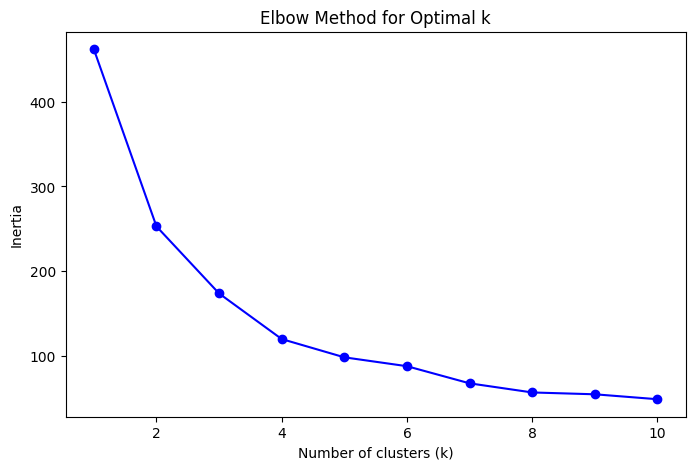

In [56]:
inertia = []
K = range(1, 11)  # test k from 1 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

By looking at the elbow graph, we can assume that the best number of clusters (n_cluster) is between 2-6 inclusive.
Assuming that By looking at the elbow graph, we can assume that, we check for the silhouette score of each number of cluster for each model.

In [57]:
for k in range(2, 7):
    model = KMeans(n_clusters=k).fit(X_pca)
    label = model.labels_
    sil_coeff = silhouette_score(X_pca, label, metric='euclidean')
    print("KMeans n_clusters={}, Silhouette {:.3f}".format(k, sil_coeff))

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k).fit(X_pca)
    label = model.labels_
    sil_coeff = silhouette_score(X_pca, label, metric='euclidean')
    print("Agglomerative n_clusters={}, Silhouette {:.3f}".format(k, sil_coeff))

for k in range(2, 7):
    model = GaussianMixture(n_components=k, random_state=42).fit(X_pca)
    label = model.predict(X_pca)
    sil_coeff = silhouette_score(X_pca, label, metric='euclidean')
    print("GMM n_components={}, Silhouette {:.3f}".format(k, sil_coeff))

KMeans n_clusters=2, Silhouette 0.423
KMeans n_clusters=3, Silhouette 0.371
KMeans n_clusters=4, Silhouette 0.410
KMeans n_clusters=5, Silhouette 0.395
KMeans n_clusters=6, Silhouette 0.384
Agglomerative n_clusters=2, Silhouette 0.397
Agglomerative n_clusters=3, Silhouette 0.367
Agglomerative n_clusters=4, Silhouette 0.340
Agglomerative n_clusters=5, Silhouette 0.332
Agglomerative n_clusters=6, Silhouette 0.353
GMM n_components=2, Silhouette 0.413
GMM n_components=3, Silhouette 0.392
GMM n_components=4, Silhouette 0.373
GMM n_components=5, Silhouette 0.349
GMM n_components=6, Silhouette 0.353


#### Model Results

- All models show the best score at number of clusters=2.
- KMeans shows the highest score compare to other models.
- It is safe to assume that number of clusters 2 is the best.

In [37]:
for eps in [0.1, 0.5, 1]:
    for sample in range (2,7):
        model = DBSCAN(eps=eps, min_samples=sample).fit(X_pca)
        label = model.labels_
        if len(set(label)) > 1 and -1 not in set(label):  # silhouette requires ≥2 clusters
            sil_coeff = silhouette_score(X_pca, label, metric='euclidean')
            print("DBSCAN eps={}, sample={}, Silhouette {:.3f}".format(eps,sample, sil_coeff))
        else:
            print("DBSCAN eps={}, Silhouette not defined (only one cluster or noise)")

DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps=0.5, sample=2, Silhouette 0.104
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)
DBSCAN eps={}, Silhouette not defined (only one cluster or noise)


#### DBSCAN Results
- Most eps/min_samples combinations produced only noise or a single cluster.
- Only eps=0.5 gave a valid silhouette (0.104), which is very low.
- Conclusion: DBSCAN does not reveal meaningful clusters in this dataset.
- KMeans and PCA-based clustering provide stronger, more interpretable segments.

### 4.4 Testing with Hierarchical Clustering Model

#### 4.4.1 Plotting Hierarchy Graph

In order to see the number of cluster at different height, we plot the dendrogram first.

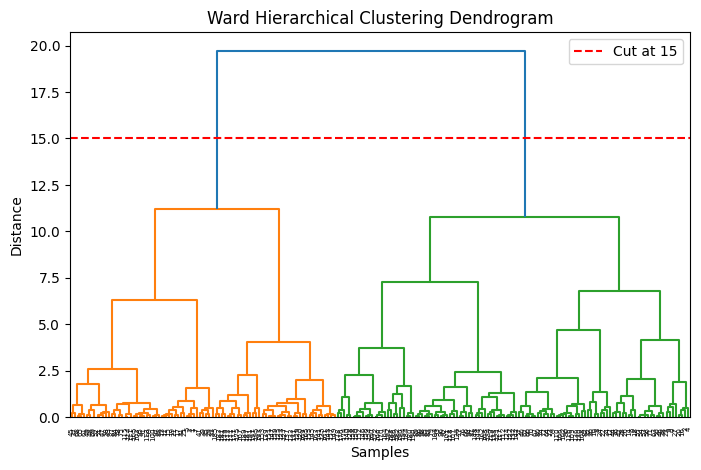

In [25]:
linked = linkage(X_pca, method='ward')
plt.figure(figsize=(8,5))
dendrogram(linked, orientation='top', distance_sort='descending')
plt.axhline(y=15, color='red', linestyle='--', label='Cut at 15')
plt.title("Ward Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.legend()
plt.show()

#### 4.4.2 Feature Importance when we choose 2 clusters

In [63]:
labels = fcluster(linked, t=15, criterion='distance')  # cut at distance=15 to get two clusters
data = pd.DataFrame(X, columns=['Age','Income_k','Spending','Gender'])
data['Cluster'] = labels
cluster_summary = data.groupby('Cluster').mean()
print(cluster_summary)

              Age  Income_k  Spending    Gender
Cluster                                        
1        0.582309 -0.055203 -0.631369  0.548673
2       -0.774129  0.073387  0.839350  0.588235


#### Reflection on Hierarchical Clustering (Ward’s Method)
- Cutting at distance=15 produced 2 clusters.
- Cluster 1: Older, average income, lower spending.
- Cluster 2: Younger, slightly higher income, higher spending.
- Gender distribution is balanced, not a key driver.
- Decision: Two clusters provide clear, interpretable customer segments consistent with PCA/KMeans results.

### 4.5 Clustering Visualization with Best k

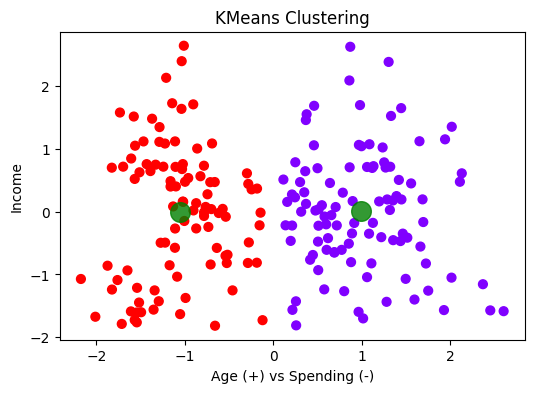

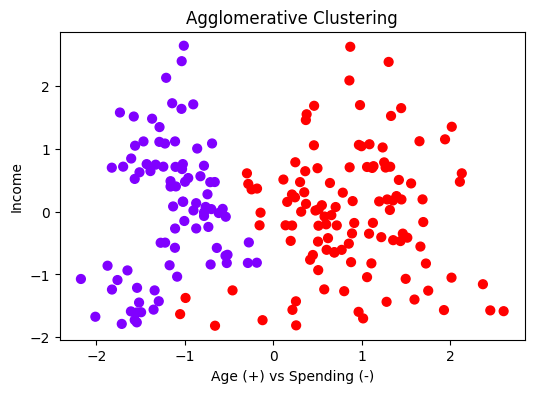

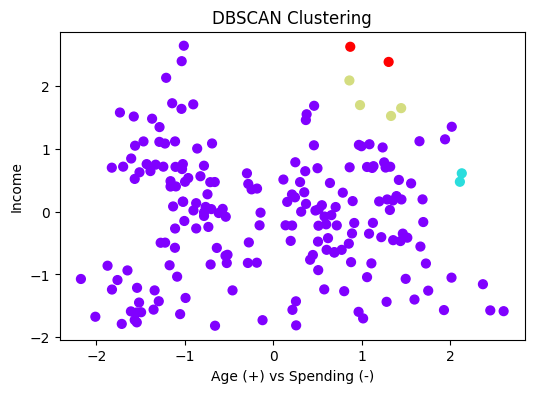

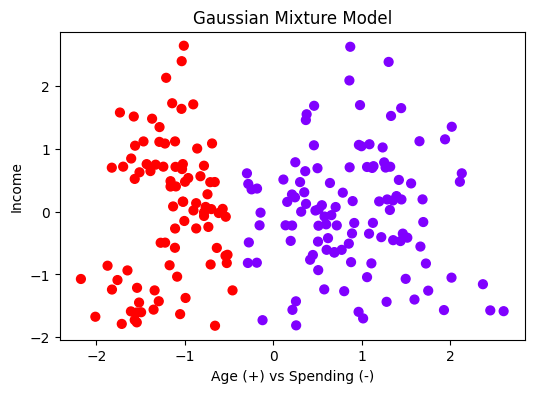

In [20]:
# 1. KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)
plot_clusters(X_pca, labels_kmeans, "KMeans Clustering", centers=kmeans.cluster_centers_)

# 2. Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X_pca)
plot_clusters(X_pca, labels_agg, "Agglomerative Clustering")

# 3. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=2)
labels_dbscan = dbscan.fit_predict(X_pca)
plot_clusters(X_pca, labels_dbscan, "DBSCAN Clustering")

# 4. Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)
plot_clusters(X_pca, labels_gmm, "Gaussian Mixture Model")

#### Reflection on Clustering with Best k
- All models except DBSCAN gives distinct clusters.
- The PCA scatter plot shows two well‑separated clusters.  
- Cluster 1:Younger, higher‑spending customers with moderate income.  
- Cluster 2: Older, lower‑spending customers with moderate income. 
- Gender did not strongly influence clustering.  
- This confirms that Age and Spending are the main drivers of segmentation, with Income providing secondary variance.  
- Two clusters provide clear, interpretable customer segments consistent with hierarchical clustering results.

## 5 Final Conclusion

### 5.1 Cluster Summary Table

In [21]:
df["Cluster"] = labels_kmeans
df.groupby("Cluster")[["Age", "Income_k", "Spending"]].mean().round(2)


,Age,Income_k,Spending
Cluster,,,
0,0.71,-0.0,-0.70
1,-0.76,0.0,0.74


**Cluster Summary (Standardized Means)**  
(Values are z‑scores: positive = above average, negative = below average.)

- **Cluster 1:** Age **+0.71**, Income **0.00**, Spending **−0.70**  
   Older than average, average income, **low spending**.

- **Cluster 2:** Age **−0.76**, Income **0.00**, Spending **+0.74**  
   Younger than average, average income, **high spending**.

**Interpretation:**  
The key difference between clusters is **spending behavior**, not income.  
Cluster 1 (younger, high spending) is the **priority segment** for premium offers and upselling.  
Cluster 0 (older, low spending) may respond better to value‑based promotions.


### Final Conclusion on Customer Segmentation
Across multiple clustering methods (KMeans, Hierarchical Ward, GMM), the data consistently forms two distinct and interpretable clusters. DBSCAN did not reveal meaningful structure, confirming that density-based methods are less suitable for this dataset.

- **Cluster 1** represents older customers with average income and lower spending.  
- **Cluster 2** represents younger customers with slightly higher income and higher spending.  

Gender distribution is balanced across both clusters, indicating it is not a key driver of segmentation.  
Age and Spending emerge as the primary differentiators, with Income providing secondary variance.  

Reducing to 2 PCA components captured 72% of the variance and allowed clear visualization of these segments.  
The two-cluster solution is both statistically supported (silhouette scores, explained variance) and practically interpretable, making it the optimal segmentation choice.

### Final Conclusion (Business Perspective)
Customer segmentation reveals two clear groups:

- **Cluster 1:** Older customers with average income who spend less.  
- **Cluster 2:** Younger customers with slightly higher income who spend more.  

Gender is not a major factor in spending behavior.  
This means marketing strategies should focus on **younger, high‑spending customers** for premium offers, loyalty programs, and upselling opportunities.  

Meanwhile, **older, lower‑spending customers** may respond better to value‑driven promotions, discounts, or bundled deals.  

By targeting these segments differently, businesses can maximize engagement and revenue while keeping strategies simple and actionable.
